Разметка корпуса + лингвистический анализ по онтологии
ВКР: Языковые маркеры депрессии и тревожности в социальных сетях

Категории онтологии (Al-Mosaiwi & Johnstone, 2018):
- depression_keywords: Основа разметки — score депрессии
- anxiety_keywords: Основа разметки — score тревоги
- absolutist_words: Ключевой маркер: частота в депрессии > тревоге > норме
- pronouns: Маркер: «я» чаще в депрессии, «мы» — в норме
- negative_emotion_words: Эмоциональная интенсивность
- certainty_words: Контраст: абсолютизм (депрессия) vs неуверенность (тревога)
- swear_words: Эмоциональные усилители

In [1]:
# 0. Установка и импорты

!pip install -q matplotlib seaborn scipy

import os, shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from scipy import stats

In [2]:
# 1. Загрузка текстов

from google.colab import drive
drive.mount('/content/drive')

# ── ПОМЕНЯЙ НА СВОЙ ПУТЬ ──────────────────────────────────────────
BASE_PATH = Path('/content/drive/MyDrive/SFU 4/VKR/1. processed')
LEMMA_DIR = BASE_PATH / 'Lemma'
# ──────────────────────────────────────────────────────────────────

FOLDERS = ['redd_p', 'redd_c', 'reda_p', 'reda_c', 'tgd_p', 'tga_p']

records = []
for folder in FOLDERS:
    folder_path = LEMMA_DIR / folder
    if not folder_path.exists():
        print(f'⚠️  Не найдено: {folder_path}')
        continue
    files = list(folder_path.glob('*.txt'))
    print(f'{folder}: {len(files)} файлов')
    for fpath in files:
        try:
            text = fpath.read_text(encoding='utf-8').strip()
            if len(text) < 5:
                continue
            records.append({
                'filepath': str(fpath),
                'filename': fpath.name,
                'folder': folder,
                'hashtag_label': 'depression' if 'd' in folder else 'anxiety',
                'source': 'reddit' if folder.startswith('red') else 'telegram',
                'type': 'comment' if folder.endswith('_c') else 'post',
                'text': text
            })
        except Exception as e:
            print(f'  Ошибка {fpath.name}: {e}')

df = pd.DataFrame(records)
print(f'\nИтого: {len(df)} текстов')

Mounted at /content/drive
redd_p: 100 файлов
redd_c: 5570 файлов
reda_p: 70 файлов
reda_c: 2666 файлов
tgd_p: 591 файлов
tga_p: 288 файлов

Итого: 8723 текстов


In [3]:
# 2. Полная онтология

ontology = {
    'depression_keywords': {
        'основные_термины': [
            'депрессия', 'депрессивный', 'депрессивное', 'депрессивной',
            'депрессивные', 'депрессивных', 'депрессивным', 'депрессивными'
        ],
        'симптомы_эмоциональные': [
            'грусть', 'грустный', 'грустно', 'печаль', 'печальный', 'печально',
            'тоска', 'тоскливый', 'тоскливо', 'уныние', 'унылый', 'уныло',
            'безнадежность', 'безнадежный', 'безнадежно', 'беспомощность',
            'опустошенность', 'опустошенный', 'апатия', 'апатичный',
            'безразличие', 'безразличный', 'одиночество', 'одинокий',
            'подавленность', 'подавленный', 'угнетение', 'угнетенный'
        ],
        'симптомы_когнитивные': [
            'нерешительность', 'неуверенность', 'забывчивость',
            'самооценка', 'вина', 'виноватый',
            'суицид', 'суицидальный', 'самоубийство', 'смерть', 'умереть'
        ],
        'симптомы_физические': [
            'усталость', 'утомление', 'бессонница', 'упадок', 'слабость', 'слабый'
        ],
        'симптомы_поведенческие': ['изоляция', 'отказ'],
        'описательные_фразы': ['бессмысленно', 'пустота', 'опустошенность', 'безысходность']
    },
    'anxiety_keywords': {
        'основные_термины': [
            'тревога', 'тревожный', 'тревожность', 'тревожно',
            'беспокойство', 'беспокойный', 'волнение'
        ],
        'симптомы_эмоциональные': [
            'страх', 'страшный', 'страшно', 'испуг', 'паника',
            'панический', 'нервозность', 'нервный',
            'раздражительность', 'напряжение', 'напряженный', 'опасение'
        ],
        'симптомы_когнитивные': [
            'навязчивый', 'обсессия', 'катастрофизация',
            'контроль', 'накручивать', 'прокручивать'
        ],
        'симптомы_физические': [
            'сердцебиение', 'дрожь', 'тремор', 'потливость',
            'одышка', 'головокружение', 'тошнота'
        ],
        'симптомы_поведенческие': ['избегание', 'избегать', 'перепроверять', 'ритуал'],
        'описательные_фразы': ['беспокоиться', 'успокоиться', 'расслабиться']
    },
    'absolutist_words': {
        'универсальные_кванторы': [
            'всегда', 'никогда', 'всё', 'ничего', 'каждый', 'никто',
            'все', 'всех', 'всеми', 'везде', 'нигде', 'повсюду',
            'постоянно', 'вечно', 'бесконечно', 'навсегда',
            'полностью', 'абсолютно', 'совершенно', 'целиком'
        ],
        'категоричные_утверждения': [
            'невыносимо', 'нестерпимо', 'немыслимо', 'нереально',
            'невозможно', 'безнадежно', 'бесполезно', 'бессмысленно',
            'обязательно', 'непременно', 'неизбежно', 'фатально'
        ],
        'крайние_оценки': [
            'ужасно', 'кошмарно', 'отвратительно', 'чудовищно',
            'жутко', 'страшно'
        ],
        'экстремальные_интенсификаторы': [
            'чрезвычайно', 'крайне', 'максимально', 'предельно',
            'безумно', 'невероятно', 'неимоверно', 'адски', 'дико', 'бешено'
        ]
    },
    'pronouns': {
        'первое_лицо_ед': [
            'я', 'меня', 'мне', 'мной', 'мною', 'себя', 'себе', 'собой',
            'мой', 'моя', 'моё', 'мои', 'моего', 'моей', 'моим', 'мою'
        ],
        'первое_лицо_мн': [
            'мы', 'нас', 'нам', 'нами',
            'наш', 'наша', 'наше', 'наши', 'нашего', 'нашей', 'нашим'
        ],
        'второе_лицо': [
            'ты', 'тебя', 'тебе', 'тобой', 'вы', 'вас', 'вам', 'вами',
            'твой', 'твоя', 'твоё', 'твои', 'ваш', 'ваша', 'ваше', 'ваши'
        ],
        'третье_лицо': [
            'он', 'она', 'оно', 'они', 'его', 'её', 'их', 'ему', 'ей', 'им'
        ]
    },
    'negative_emotion_words': {
        'базовые_негативные': [
            'грусть', 'печаль', 'тоска', 'уныние', 'скорбь', 'горе',
            'страх', 'ужас', 'испуг', 'боязнь', 'трепет',
            'гнев', 'злость', 'ярость', 'раздражение', 'ненависть',
            'отвращение', 'презрение', 'неприязнь',
            'вина', 'стыд', 'позор', 'раскаяние', 'сожаление'
        ],
        'депрессивная_лексика': [
            'безнадежность', 'беспомощность', 'никчемность', 'ничтожность',
            'бессмысленность', 'пустота', 'опустошенность',
            'отчаяние', 'безысходность', 'обреченность', 'беспросветность'
        ],
        'тревожная_лексика': [
            'тревога', 'беспокойство', 'опасение', 'нервозность',
            'напряжение', 'скованность', 'зажатость',
            'сомнение', 'мнительность', 'подозрительность'
        ]
    },
    'certainty_words': {
        'высокая_уверенность': [
            'уверен', 'убежден', 'несомненно', 'безусловно',
            'точно', 'стопроцентно', 'гарантированно', 'железно', 'бесспорно'
        ],
        'низкая_уверенность': [
            'сомневаюсь', 'возможно', 'наверное', 'вероятно',
            'кажется', 'похоже', 'скорее всего', 'наверно',
            'пожалуй', 'вряд ли', 'едва ли', 'сомнительно'
        ]
    },
    'swear_words': {
        'мат': [
            'блять', 'блядь', 'бля', 'хуй', 'хуйня',
            'пиздец', 'ебать', 'ебанутый', 'нахуй', 'нахер',
            'херня', 'хер', 'хрен', 'хреново'
        ],
        'эвфемизмы': [
            'блин', 'чёрт', 'ёлки', 'елки'
        ],
        'интенсификаторы': [
            'охренеть', 'офигеть', 'охрененный', 'офигенный'
        ]
    }
}


def flatten(d):
    words = set()
    for v in d.values():
        if isinstance(v, list):
            words.update(v)
        elif isinstance(v, dict):
            words.update(flatten(v))
    return words

# Основные словари для разметки (ИЗ ОНТОЛОГИИ)
DEP_WORDS = flatten(ontology['depression_keywords'])
ANX_WORDS = flatten(ontology['anxiety_keywords'])

# Убираем пересечение в исходных словарях
overlap = DEP_WORDS & ANX_WORDS
DEP_WORDS -= overlap
ANX_WORDS -= overlap

# Вспомогательные категории для анализа
ABS_WORDS = flatten(ontology['absolutist_words'])
PRON_1SG  = set(ontology['pronouns']['первое_лицо_ед'])
PRON_1PL  = set(ontology['pronouns']['первое_лицо_мн'])
PRON_2    = set(ontology['pronouns']['второе_лицо'])
PRON_3    = set(ontology['pronouns']['третье_лицо'])
NEG_EMO   = flatten(ontology['negative_emotion_words'])
CERT_HIGH = set(ontology['certainty_words']['высокая_уверенность'])
CERT_LOW  = set(ontology['certainty_words']['низкая_уверенность'])
SWEAR     = flatten(ontology['swear_words'])

print('Исходные словари (до расширения):')
print(f'Словарь депрессии: {len(DEP_WORDS)} слов')
print(f'Словарь тревоги:   {len(ANX_WORDS)} слов')
print(f'Абсолютистские:    {len(ABS_WORDS)} слов')
print()

# ===== ТЕПЕРЬ РАСШИРЕНИЕ =====
EXTRA_DEPRESSION = {
    'антидепрессант', 'антидепрессанты', 'психиатр', 'психиатра',
    'психолог', 'психолога', 'терапевт', 'психотерапевт', 'психотерапевта',
    'лечение', 'лечиться', 'диагноз', 'расстройство', 'клиника', 'стационар',
    'больница', 'таблетки', 'рецепт', 'препарат', 'медикаменты',
    'выгорание', 'выгорел', 'истощение', 'опустошен', 'отчаяние',
    'безысходность', 'апатия', 'ангедония', 'срыв', 'сорвался',
    'плакать', 'плачу', 'рыдать', 'нет_сил', 'тяжело', 'подавлен',
    'сдвг', 'аутизм', 'рас', 'асд', 'побочка', 'побочки'
}

EXTRA_ANXIETY = {
    'транквилизатор', 'успокоительное', 'седативный',
    'гтр', 'птср', 'всд',
    'паниковать', 'паникую', 'паник', 'паничек',
    'атака', 'атаки', 'приступ', 'приступы',
    'нервничать', 'волноваться', 'переживать', 'бояться',
    'накручивать', 'прокручивать',
    'избегать', 'перепроверять', 'контролировать',
    'колотить', 'трястись', 'потеть', 'задыхаться',
    'сдвг', 'тревожность', 'побочка', 'побочки'
}

EXTRA_ABSOLUTIST = {
    'вообще', 'совсем', 'совершенно', 'абсолютно', 'тотально',
    'категорически', 'окончательно', 'бесповоротно',
    'безумно', 'бешено', 'дико', 'адски', 'нереально'
}

# Применяем расширение
DEP_WORDS = DEP_WORDS | EXTRA_DEPRESSION
ANX_WORDS = ANX_WORDS | EXTRA_ANXIETY
ABS_WORDS = ABS_WORDS | EXTRA_ABSOLUTIST

# Снова убираем пересечения (могли появиться новые)
overlap = DEP_WORDS & ANX_WORDS
DEP_WORDS -= overlap
ANX_WORDS -= overlap

print('После расширения:')
print(f'Словарь депрессии: {len(DEP_WORDS)} слов (+{len(EXTRA_DEPRESSION)} новых)')
print(f'Словарь тревоги:   {len(ANX_WORDS)} слов (+{len(EXTRA_ANXIETY)} новых)')
print(f'Абсолютистские:    {len(ABS_WORDS)} слов (+{len(EXTRA_ABSOLUTIST)} новых)')
print(f'Убрано пересечений после расширения: {len(overlap)}')

Исходные словари (до расширения):
Словарь депрессии: 58 слов
Словарь тревоги:   39 слов
Абсолютистские:    48 слов

После расширения:
Словарь депрессии: 95 слов (+42 новых)
Словарь тревоги:   62 слов (+31 новых)
Абсолютистские:    54 слов (+13 новых)
Убрано пересечений после расширения: 3


In [4]:
# 3. Подсчёт всех признаков

def extract_features(text):
    tokens = text.lower().split()
    token_set = set(tokens)
    n = max(len(tokens), 1)

    # Подсчёт совпадений (нормализованы на корень длины)
    def norm_count(wordset):
        return len(token_set & wordset) / np.sqrt(n)

    # Абсолютный подсчёт (для частотного анализа на 100 слов)
    def rate_per100(wordset):
        return len([t for t in tokens if t in wordset]) / n * 100

    score_dep = norm_count(DEP_WORDS)
    score_anx = norm_count(ANX_WORDS)
    abs_boost = norm_count(ABS_WORDS) * 0.3

    return pd.Series({
        # Для разметки
        'score_dep':      round(score_dep + abs_boost, 4),
        'score_anx':      round(score_anx + abs_boost, 4),

        # Лингвистические признаки (на 100 слов — удобно для сравнения)
        'abs_rate':       round(rate_per100(ABS_WORDS), 4),     # абсолютистские
        'pron_1sg_rate':  round(rate_per100(PRON_1SG), 4),      # я, меня...
        'pron_1pl_rate':  round(rate_per100(PRON_1PL), 4),      # мы, нас...
        'pron_2_rate':    round(rate_per100(PRON_2), 4),        # ты, вы...
        'pron_3_rate':    round(rate_per100(PRON_3), 4),        # он, она...
        'neg_emo_rate':   round(rate_per100(NEG_EMO), 4),       # негативные эмоции
        'cert_high_rate': round(rate_per100(CERT_HIGH), 4),     # высокая уверенность
        'cert_low_rate':  round(rate_per100(CERT_LOW), 4),      # низкая уверенность
        'swear_rate':     round(rate_per100(SWEAR), 4),         # мат/эвфемизмы
        'n_tokens':       n,

        # Для отладки
        'dep_words_found': ', '.join(sorted(token_set & DEP_WORDS)[:6]),
        'anx_words_found': ', '.join(sorted(token_set & ANX_WORDS)[:6]),
    })

print('Извлекаем признаки...')
features = df['text'].apply(extract_features)
df = pd.concat([df, features], axis=1)
print('Готово ✓')
print(df[['score_dep','score_anx','abs_rate','pron_1sg_rate','neg_emo_rate']].describe().round(4))

Извлекаем признаки...
Готово ✓
       score_dep  score_anx   abs_rate  pron_1sg_rate  neg_emo_rate
count  8723.0000  8723.0000  8723.0000      8723.0000     8723.0000
mean      0.1164     0.0567     1.3259         0.3649        0.5716
std       0.1952     0.1280     4.1754         1.8888        4.3006
min       0.0000     0.0000     0.0000         0.0000        0.0000
25%       0.0000     0.0000     0.0000         0.0000        0.0000
50%       0.0000     0.0000     0.0000         0.0000        0.0000
75%       0.1840     0.0600     0.0000         0.0000        0.0000
max       1.4142     1.4142   100.0000        50.0000      100.0000


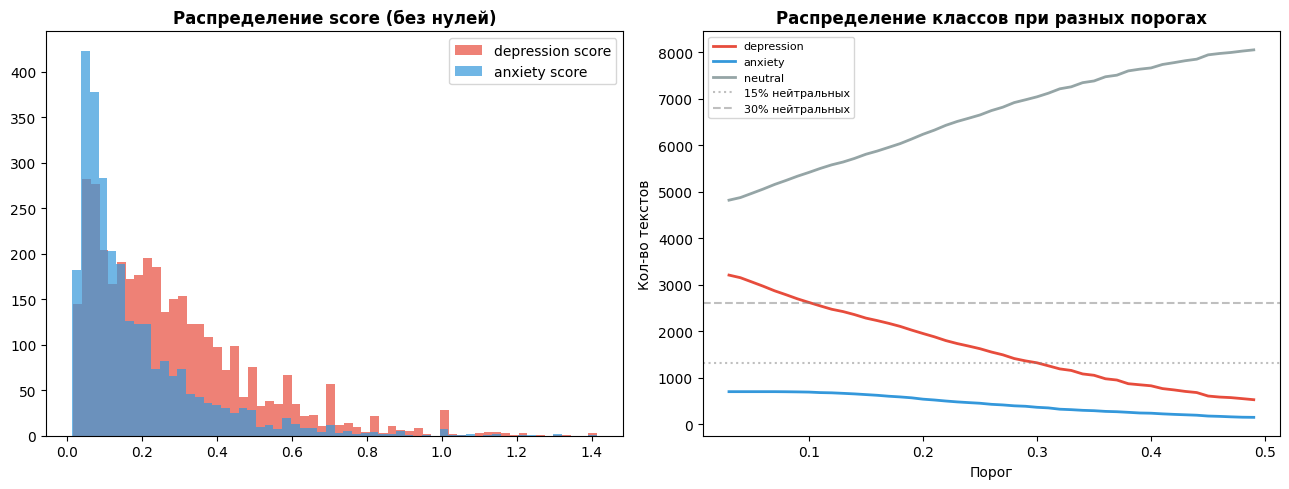

Перцентили score_dep: [0.    0.    0.    0.184]
Перцентили score_anx: [0.   0.   0.   0.06]
Порог: 0.15
  neutral: 5775 (66.2%)
  depression: 2310 (26.5%)
  anxiety: 638 (7.3%)

── Проверка нейтральных (5 примеров) ──
  [reda_c] dep=0.000 anx=0.000
  хотеться саба политика пообсуждать дяденька

  [redd_c] dep=0.000 anx=0.000
  дружба рамка насколько знать вести встречаться этот девушка хотя отрицать это

  [reda_c] dep=0.100 anx=0.100
  нахуй выходить топика автор хуйня показаться всё вместе около

  [reda_c] dep=0.000 anx=0.000
  поинтересоваться возраст всякий случай молодой оказаться ты казаться старший целое признак груминг поостеречься спрашивать девочка год молодой мочь от

  [redd_c] dep=0.000 anx=0.000
  потратить быть жить долго счастливо отличие некоторый



In [7]:
# 4. Разметка: подбор порога

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Гистограммы score
axes[0].hist(df['score_dep'][df['score_dep']>0], bins=60,
             color='#e74c3c', alpha=0.7, label='depression score')
axes[0].hist(df['score_anx'][df['score_anx']>0], bins=60,
             color='#3498db', alpha=0.7, label='anxiety score')
axes[0].set_title('Распределение score (без нулей)', fontweight='bold')
axes[0].legend()

# Как меняется распределение при разных порогах
thresholds = np.arange(0.03, 0.5, 0.01)
n_dep, n_anx, n_neu = [], [], []
for t in thresholds:
    lab = df.apply(lambda r: 'neutral' if r['score_dep']<t and r['score_anx']<t
                   else ('depression' if r['score_dep']>=r['score_anx'] else 'anxiety'), axis=1)
    n_dep.append((lab=='depression').sum())
    n_anx.append((lab=='anxiety').sum())
    n_neu.append((lab=='neutral').sum())

axes[1].plot(thresholds, n_dep, color='#e74c3c', lw=2, label='depression')
axes[1].plot(thresholds, n_anx, color='#3498db', lw=2, label='anxiety')
axes[1].plot(thresholds, n_neu, color='#95a5a6', lw=2, label='neutral')
axes[1].axhline(len(df)*0.15, color='gray', ls=':', alpha=0.5, label='15% нейтральных')
axes[1].axhline(len(df)*0.30, color='gray', ls='--', alpha=0.5, label='30% нейтральных')
axes[1].set_xlabel('Порог')
axes[1].set_ylabel('Кол-во текстов')
axes[1].set_title('Распределение классов при разных порогах', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SFU 4/VKR/3. labeling/Словарная разметка/pngs/threshold_choice.png', dpi=150)
plt.show()
print('Перцентили score_dep:', np.percentile(df['score_dep'], [10,25,50,75]).round(4))
print('Перцентили score_anx:', np.percentile(df['score_anx'], [10,25,50,75]).round(4))

# ── ВЫБЕРИ ПОРОГ ──────────────────────────────────────────────────
THRESHOLD = 0.15  # ← меняй, смотри на правый график выше
# ─────────────────────────────────────────────────────────────────

df['label'] = df.apply(
    lambda r: 'neutral' if r['score_dep'] < THRESHOLD and r['score_anx'] < THRESHOLD
    else ('depression' if r['score_dep'] >= r['score_anx'] else 'anxiety'),
    axis=1
)

print(f'Порог: {THRESHOLD}')
for cls, n in df['label'].value_counts().items():
    print(f'  {cls}: {n} ({n/len(df)*100:.1f}%)')

# Быстрая ручная проверка
print('\n── Проверка нейтральных (5 примеров) ──')
for _, r in df[df['label']=='neutral'].sample(5, random_state=42).iterrows():
    print(f'  [{r["folder"]}] dep={r["score_dep"]:.3f} anx={r["score_anx"]:.3f}')
    print(f'  {r["text"][:150]}')
    print()

═══ Среднее значение признаков (на 100 слов) по классам ═══
label                        depression  anxiety  neutral
Абсолютистские слова             2.2878   2.1213   0.8534
Местоимения 1 л. ед.ч. (я)       0.4487   0.3975   0.3278
Местоимения 1 л. мн.ч. (мы)      0.1210   0.2501   0.3971
Местоимения 2 л. (ты/вы)         1.0527   0.8729   1.2019
Местоимения 3 л. (он/она)        0.2799   0.4583   0.2341
Негативные эмоции                0.7957   2.3264   0.2882
Высокая уверенность              0.1151   0.0562   0.1073
Низкая уверенность               0.2459   0.1891   0.3379
Мат / эвфемизмы                  0.2298   0.2134   0.6628

Сохранено: linguistic_features_by_class.csv
═══ Статистическая значимость (Kruskal-Wallis H-test) ═══
Признак                                    H-stat      p-value    Значимо
───────────────────────────────────────────────────────────────────────────
Абсолютистские слова                       779.03     0.000000  ✓ p<0.001
Местоимения 1 л. ед.ч. (я)       

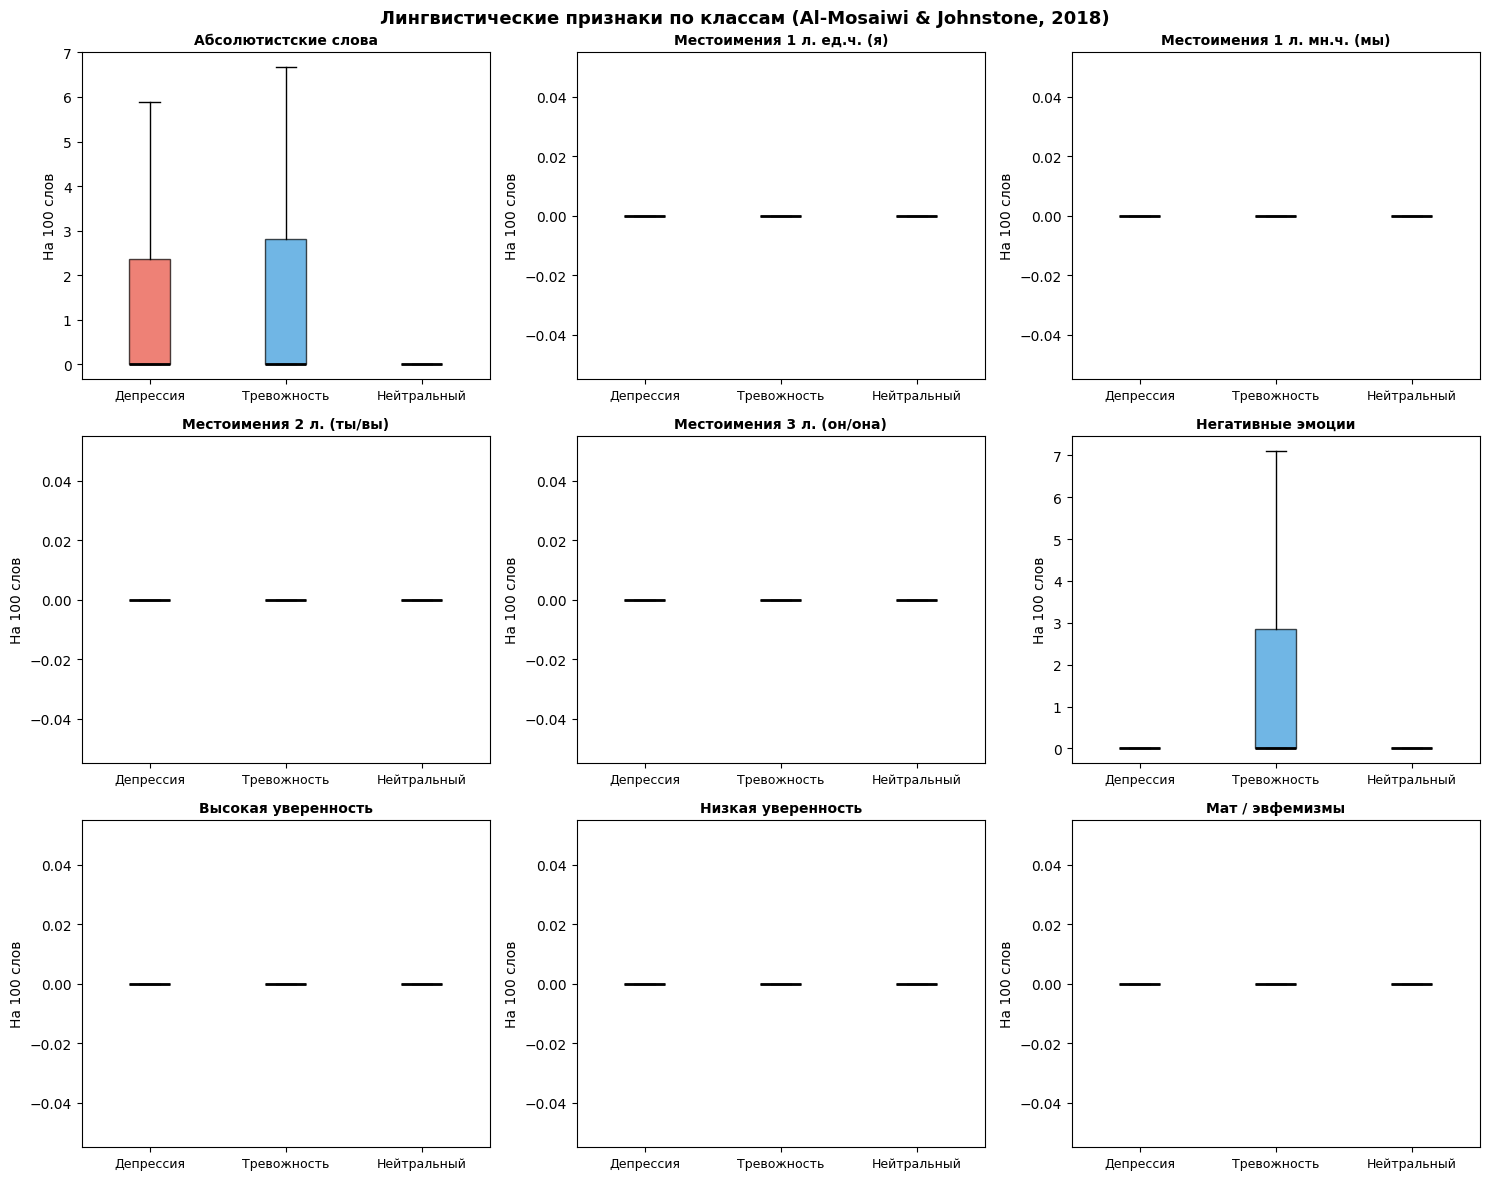

Сохранено: linguistic_features_boxplot.png — вставляй в ВКР!


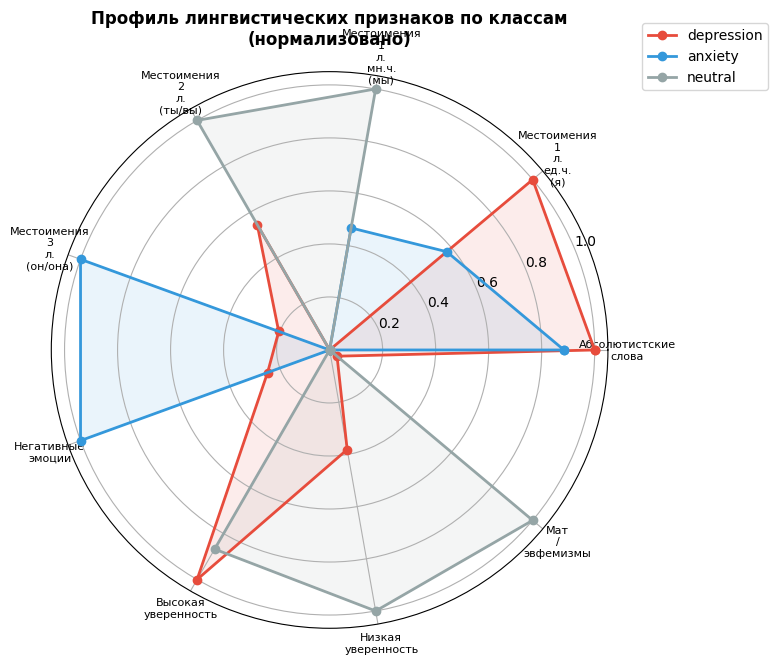

Сохранено: radar_chart.png


In [9]:
# 5. Лингвистический анализ по категориям онтологии. Сравниваем признаки между классами

FEATURES = [
    ('abs_rate',       'Абсолютистские слова'),
    ('pron_1sg_rate',  'Местоимения 1 л. ед.ч. (я)'),
    ('pron_1pl_rate',  'Местоимения 1 л. мн.ч. (мы)'),
    ('pron_2_rate',    'Местоимения 2 л. (ты/вы)'),
    ('pron_3_rate',    'Местоимения 3 л. (он/она)'),
    ('neg_emo_rate',   'Негативные эмоции'),
    ('cert_high_rate', 'Высокая уверенность'),
    ('cert_low_rate',  'Низкая уверенность'),
    ('swear_rate',     'Мат / эвфемизмы'),
]

LABELS = ['depression', 'anxiety', 'neutral']
colors = {'depression': '#e74c3c', 'anxiety': '#3498db', 'neutral': '#95a5a6'}

# Сводная таблица: среднее на 100 слов по классам
summary = df.groupby('label')[[f for f, _ in FEATURES]].mean().round(4)
summary.columns = [n for _, n in FEATURES]
summary = summary.reindex(LABELS)

print('═══ Среднее значение признаков (на 100 слов) по классам ═══')
print(summary.T.to_string())

# Сохраняем в CSV — это таблица для ВКР!
summary.T.to_csv('/content/drive/MyDrive/SFU 4/VKR/3. labeling/Словарная разметка/pngs/linguistic_features_by_class.csv', encoding='utf-8-sig')
print('\nСохранено: linguistic_features_by_class.csv')

# Статистическая значимость различий (критерий Краскела-Уоллиса)
# Непараметрический — подходит для текстовых данных (нет нормального распределения)
print('═══ Статистическая значимость (Kruskal-Wallis H-test) ═══')
print(f'{"Признак":<40} {"H-stat":>8} {"p-value":>12} {"Значимо":>10}')
print('─' * 75)

sig_results = []
for feat, name in FEATURES:
    groups = [df[df['label']==cls][feat].values for cls in LABELS]
    # Убираем пустые группы
    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
        h, p = stats.kruskal(*groups)
        sig = '✓ p<0.001' if p < 0.001 else ('✓ p<0.05' if p < 0.05 else '✗')
        print(f'{name:<40} {h:>8.2f} {p:>12.6f} {sig:>10}')
        sig_results.append({'Признак': name, 'H': round(h,2), 'p': round(p,6), 'Значимо': p < 0.05})

sig_df = pd.DataFrame(sig_results)
sig_df.to_csv('/content/drive/MyDrive/SFU 4/VKR/3. labeling/Словарная разметка/pngs/statistical_significance.csv', index=False, encoding='utf-8-sig')
print('\nСохранено: statistical_significance.csv')

# Визуализация — boxplot для каждого признака
n_features = len(FEATURES)
cols = 3
rows = (n_features + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

for i, (feat, name) in enumerate(FEATURES):
    ax = axes[i]
    data_by_class = [df[df['label']==cls][feat].values for cls in LABELS]
    bp = ax.boxplot(data_by_class, patch_artist=True, showfliers=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, cls in zip(bp['boxes'], LABELS):
        patch.set_facecolor(colors[cls])
        patch.set_alpha(0.7)
    ax.set_xticklabels(['Депрессия', 'Тревожность', 'Нейтральный'], fontsize=9)
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_ylabel('На 100 слов')

# Убираем лишние оси
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Лингвистические признаки по классам (Al-Mosaiwi & Johnstone, 2018)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SFU 4/VKR/3. labeling/Словарная разметка/pngs/linguistic_features_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: linguistic_features_boxplot.png — вставляй в ВКР!')

# Радарная диаграмма — красиво для ВКР
feat_names = [n for _, n in FEATURES]
feat_cols  = [f for f, _ in FEATURES]

# Нормализуем от 0 до 1 для радара
means = df.groupby('label')[feat_cols].mean()
means_norm = (means - means.min()) / (means.max() - means.min() + 1e-9)

N = len(feat_cols)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for cls in LABELS:
    if cls not in means_norm.index:
        continue
    values = means_norm.loc[cls, feat_cols].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', lw=2, color=colors[cls], label=cls)
    ax.fill(angles, values, alpha=0.1, color=colors[cls])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([n.replace(' ', '\n') for n in feat_names], fontsize=8)
ax.set_title('Профиль лингвистических признаков по классам\n(нормализовано)',
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SFU 4/VKR/3. labeling/Словарная разметка/pngs/radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: radar_chart.png')

═══ Топ-15 абсолютистских слов по классам ═══

depression (всего слов: 141054, абсолютистских: 2488, rate: 1.76%)
  всё(708), вообще(457), каждый(328), никто(202), постоянно(107), невозможно(98), обязательно(85), абсолютно(63), полностью(61), страшно(53)

anxiety (всего слов: 49192, абсолютистских: 771, rate: 1.57%)
  всё(225), вообще(126), каждый(104), страшно(77), постоянно(45), никто(29), обязательно(25), полностью(19), невозможно(17), абсолютно(14)

neutral (всего слов: 107488, абсолютистских: 1269, rate: 1.18%)
  всё(391), вообще(252), каждый(181), никто(105), постоянно(61), обязательно(40), полностью(31), совершенно(22), абсолютно(21), везде(21)

Ожидаемый паттерн по Al-Mosaiwi & Johnstone:
  depression > anxiety > neutral
═══ Среднее использование местоимений (на 100 слов) ═══
            Я (1л ед)  МЫ (1л мн)  ТЫ/ВЫ (2л)  ОН/ОНА (3л)
label                                                     
depression     0.4487      0.1210      1.0527       0.2799
anxiety        0.3975      0

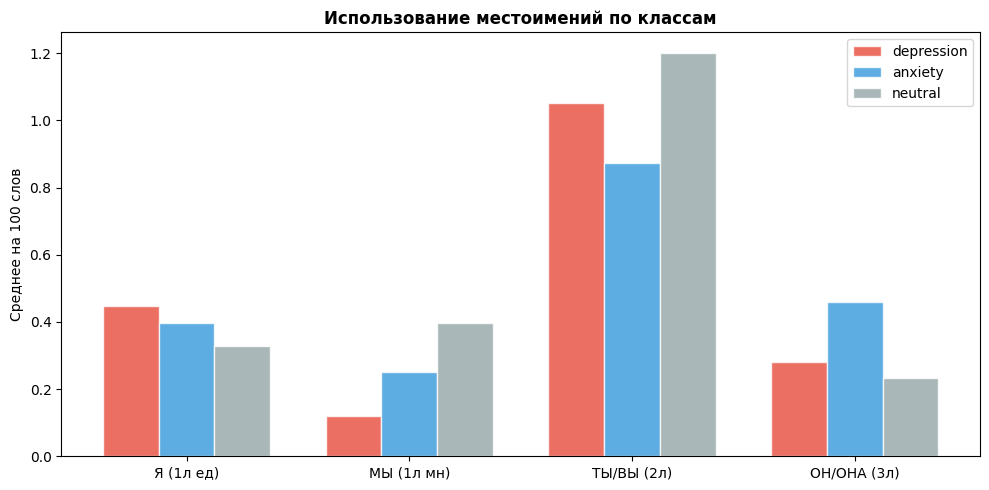


Ожидаемый паттерн: "я" больше в депрессии, "мы" больше в нейтральных


In [10]:
# 6. Детальный анализ: абсолютистские слова
# Ключевой результат Al-Mosaiwi & Johnstone (2018) — воспроизводим на своих данных

# Топ абсолютистских слов в каждом классе
from collections import Counter

print('═══ Топ-15 абсолютистских слов по классам ═══\n')
abs_table = {}
for cls in LABELS:
    texts = df[df['label']==cls]['text'].str.lower().str.split()
    all_tokens = [t for tokens in texts for t in tokens]
    abs_tokens = [t for t in all_tokens if t in ABS_WORDS]
    counter = Counter(abs_tokens)
    top = counter.most_common(15)
    abs_table[cls] = [f'{w} ({c})' for w, c in top]
    total = len(all_tokens)
    print(f'{cls} (всего слов: {total}, абсолютистских: {len(abs_tokens)}, '
          f'rate: {len(abs_tokens)/total*100:.2f}%)')
    print('  ' + ', '.join([f'{w}({c})' for w, c in top[:10]]))
    print()

# Сравнение rate абсолютистских слов — ключевая таблица для ВКР
print('Ожидаемый паттерн по Al-Mosaiwi & Johnstone:')
print('  depression > anxiety > neutral')

# Анализ местоимений — ещё один ключевой результат
print('═══ Среднее использование местоимений (на 100 слов) ═══')
pron_cols = ['pron_1sg_rate', 'pron_1pl_rate', 'pron_2_rate', 'pron_3_rate']
pron_names = ['Я (1л ед)', 'МЫ (1л мн)', 'ТЫ/ВЫ (2л)', 'ОН/ОНА (3л)']
pron_means = df.groupby('label')[pron_cols].mean().round(4)
pron_means.columns = pron_names
pron_means = pron_means.reindex(LABELS)
print(pron_means.to_string())

# Барплот местоимений
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(pron_names))
width = 0.25
for i, cls in enumerate(LABELS):
    if cls in pron_means.index:
        vals = pron_means.loc[cls].values
        ax.bar(x + i*width, vals, width, label=cls,
               color=colors[cls], alpha=0.8, edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels(pron_names)
ax.set_ylabel('Среднее на 100 слов')
ax.set_title('Использование местоимений по классам', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SFU 4/VKR/3. labeling/Словарная разметка/pngs/pronouns_analysis.png', dpi=150)
plt.show()
print('\nОжидаемый паттерн: "я" больше в депрессии, "мы" больше в нейтральных')

In [11]:
# 7. Сохранение финальных результатов

# Сохраняем полный датасет с признаками
save_cols = ['filename', 'folder', 'hashtag_label', 'source', 'type', 'label',
             'score_dep', 'score_anx', 'n_tokens'] + [f for f, _ in FEATURES]
df[save_cols].to_csv(
    '/content/drive/MyDrive/SFU 4/VKR/3. labeling/Словарная разметка/corpus_labeled_full.csv',
    index=False, encoding='utf-8-sig'
)
print('Полный датасет сохранён: corpus_labeled_full.csv')

# Копируем файлы в новые папки
OUTPUT_DIR   = Path('/content/drive/MyDrive/SFU 4/VKR/3. labeling/Словарная разметка/labeled')
for label in ['depression', 'anxiety', 'neutral']:
    (OUTPUT_DIR / label).mkdir(parents=True, exist_ok=True)

errors = []
for _, row in tqdm(df.iterrows(), total=len(df), desc='Копирование'):
    src = Path(row['filepath'])
    dst = OUTPUT_DIR / row['label'] / row['filename']
    if dst.exists():
        dst = OUTPUT_DIR / row['label'] / f"{row['folder']}_{row['filename']}"
    try:
        shutil.copy2(src, dst)
    except Exception as e:
        errors.append(str(e))

print('\nФайлов в папках:')
for label in ['depression', 'anxiety', 'neutral']:
    n = len(list((OUTPUT_DIR / label).glob('*.txt')))
    print(f'  {label}: {n}')
print('Ошибок:', len(errors) if errors else 'нет ✓')

Полный датасет сохранён: corpus_labeled_full.csv


Копирование:   0%|          | 0/8723 [00:00<?, ?it/s]


Файлов в папках:
  depression: 2310
  anxiety: 638
  neutral: 5775
Ошибок: нет ✓



📋 Для ВКР

Методология:
Разметка корпуса осуществлялась методом дистантного надзора на основе психолингвистической онтологии (Al-Mosaiwi & Johnstone, 2018). Помимо тематических словарей депрессии и тревожности, онтология включала пять дополнительных категорий: абсолютистские слова, личные местоимения, слова негативных эмоций, слова уверенности/неуверенности и ненормативную лексику. Для каждого текста извлекались нормализованные частотные признаки по каждой категории (количество вхождений на 100 слов). Статистическая значимость различий между классами проверялась с помощью непараметрического критерия Краскела-Уоллиса.

Ключевые результаты для обсуждения:
 - Подтверждается ли паттерн Al-Mosaiwi: абсолютистских слов больше в депрессии, чем в тревоге и норме?
 - Местоимение «я» чаще в депрессии — самофокусировка как маркер
 - Слова низкой уверенности («наверное», «кажется») чаще в тревоге — когнитивная неопределённость
 - Мат/эвфемизмы — в каком классе больше и что это значит

Файлы:
| Файл | Содержание |
|------|------------|
| `corpus_labeled_full.csv` | Все тексты с метками и признаками |
| `linguistic_features_by_class.csv` | Сводная таблица средних → в ВКР |
| `statistical_significance.csv` | H-статистика и p-values → в ВКР |
| `linguistic_features_boxplot.png` | Боксплоты признаков → в ВКР |
| `radar_chart.png` | Радарная диаграмма → в ВКР |
| `pronouns_analysis.png` | Анализ местоимений → в ВКР |

In [12]:
print('═══ Распределение меток по папкам ═══')
cross = pd.crosstab(df['folder'], df['label'], margins=True)
cross['neutral_%'] = (cross['neutral'] / cross['All'] * 100).round(1)
print(cross.sort_values('neutral_%', ascending=False))

print('\n═══ По типу документа ═══')
print(pd.crosstab(df['type'], df['label'], normalize='index').round(3) * 100)

═══ Распределение меток по папкам ═══
label   anxiety  depression  neutral   All  neutral_%
folder                                               
reda_c      176         493     1779  2448       72.7
redd_c      195        1300     3734  5229       71.4
All         638        2310     5775  8723       66.2
tgd_p        57         335      196   588       33.3
redd_p        3          79       18   100       18.0
tga_p       169          76       43   288       14.9
reda_p       38          27        5    70        7.1

═══ По типу документа ═══
label    anxiety  depression  neutral
type                                 
comment      4.8        23.4     71.8
post        25.5        49.4     25.0
